---

Actividad: Regresión lineal múltiple con el conjunto de datos sma (2026-07)
---

In [ ]:
# Python equivalent of R setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Configure display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Suppress warnings if needed (similar to warning = F in R)
import warnings
warnings.filterwarnings('ignore')

# Regresión lineal simple con el conjunto de datos sma

## Objetivo

En esta actividad se utilizará el conjunto de datos **sma** para estimar un modelo de regresión lineal múltiple para modelar la tasa de delitos en las áreas metropolitanas estadounidenses.  

Para esta actividad deberá:

- Estimar el modelo de regresión lineal múltiple adecuado.
- Proporción la ecuación de la recta estimada.
- Interpretar los coeficientes de regresión estimados y su signficancia.
- Realizar la prueba de signficancia general (utilice un nivel de signficancia del 5%) e intrepretar el coeficiente de determinación.
- Realizar la comprobación de supuestos.
- Redactar un resumen del análisis en el contexto del problema.


## Descripción del conjunto de datos

## Dataset: SMA  

Considere los datos sobre 141 áreas metropolitanas estándar en los Estados Unidos (sma.txt). Los datos proporcionan información sobre 11 variables para cada área para el período 1976-1977. Las zonas se han dividido en 4 regiones geográficas: 1=Noreste, 2=Norte-Centro, 3=Sur,
4=Oeste. Las variables proporcionadas son las siguientes:  


Área: tamaño de la tierra en millas cuadradas  
Población total: estimada en miles  
Porcentaje ciudad:  porcentaje de la población en el centro de la ciudad / ciudades  
Porcentaje senior: porcentaje de personas mayores de $\leq$ 65 años  
Médicos: número de médicos profesionalmente activos    
Camas de hospital: número total de camas de hospital    
Graduados:  porcentaje de adultos que terminaron la escuela secundaria    
Laboral: número de personas en la fuerza laboral en miles    
Ingresos: ingresos totales en 1976 en millones de dólares    
Delitos: número de delitos graves    
Región: región geográfica según el Censo de los Estados Unidos: 1=Noreste, 2=Norte-Centro, 3=Sur, 4=Oeste  

La variable respuesta que estamos interesados en modelar es la tasa de delitos por cada mil habitantes (Delitos/Población total).

# Paso 1. Lectura del conjunto de datos

In [ ]:
sma = pd.read_csv("sma.txt", delim_whitespace=True, header=None, index_col=0) # Read as whitespace-separated, no header, first column as index
sma.columns = ['Area', 'PobT', 'PCiudad', 'PSenior', 'Medicos', 'CHosp', 'Grad', 'Laboral', 'Ingresos', 'Delitos', 'Region']

# Variable de respuesta
sma['TDelitos'] = sma['Delitos'] / sma['PobT']

print(sma.info()) # Equivalent to str(sma) for DataFrame structure

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 1 to 141
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Area      141 non-null    int64  
 1   PobT      141 non-null    int64  
 2   PCiudad   141 non-null    float64
 3   PSenior   141 non-null    float64
 4   Medicos   141 non-null    int64  
 5   CHosp     141 non-null    int64  
 6   Grad      141 non-null    float64
 7   Laboral   141 non-null    float64
 8   Ingresos  141 non-null    int64  
 9   Delitos   141 non-null    int64  
 10  Region    141 non-null    int64  
 11  TDelitos  141 non-null    float64
dtypes: float64(5), int64(7)
memory usage: 14.3 KB
None


# Paso 2. Preparación del conjunto de datos para el análisis y exploración gráfica

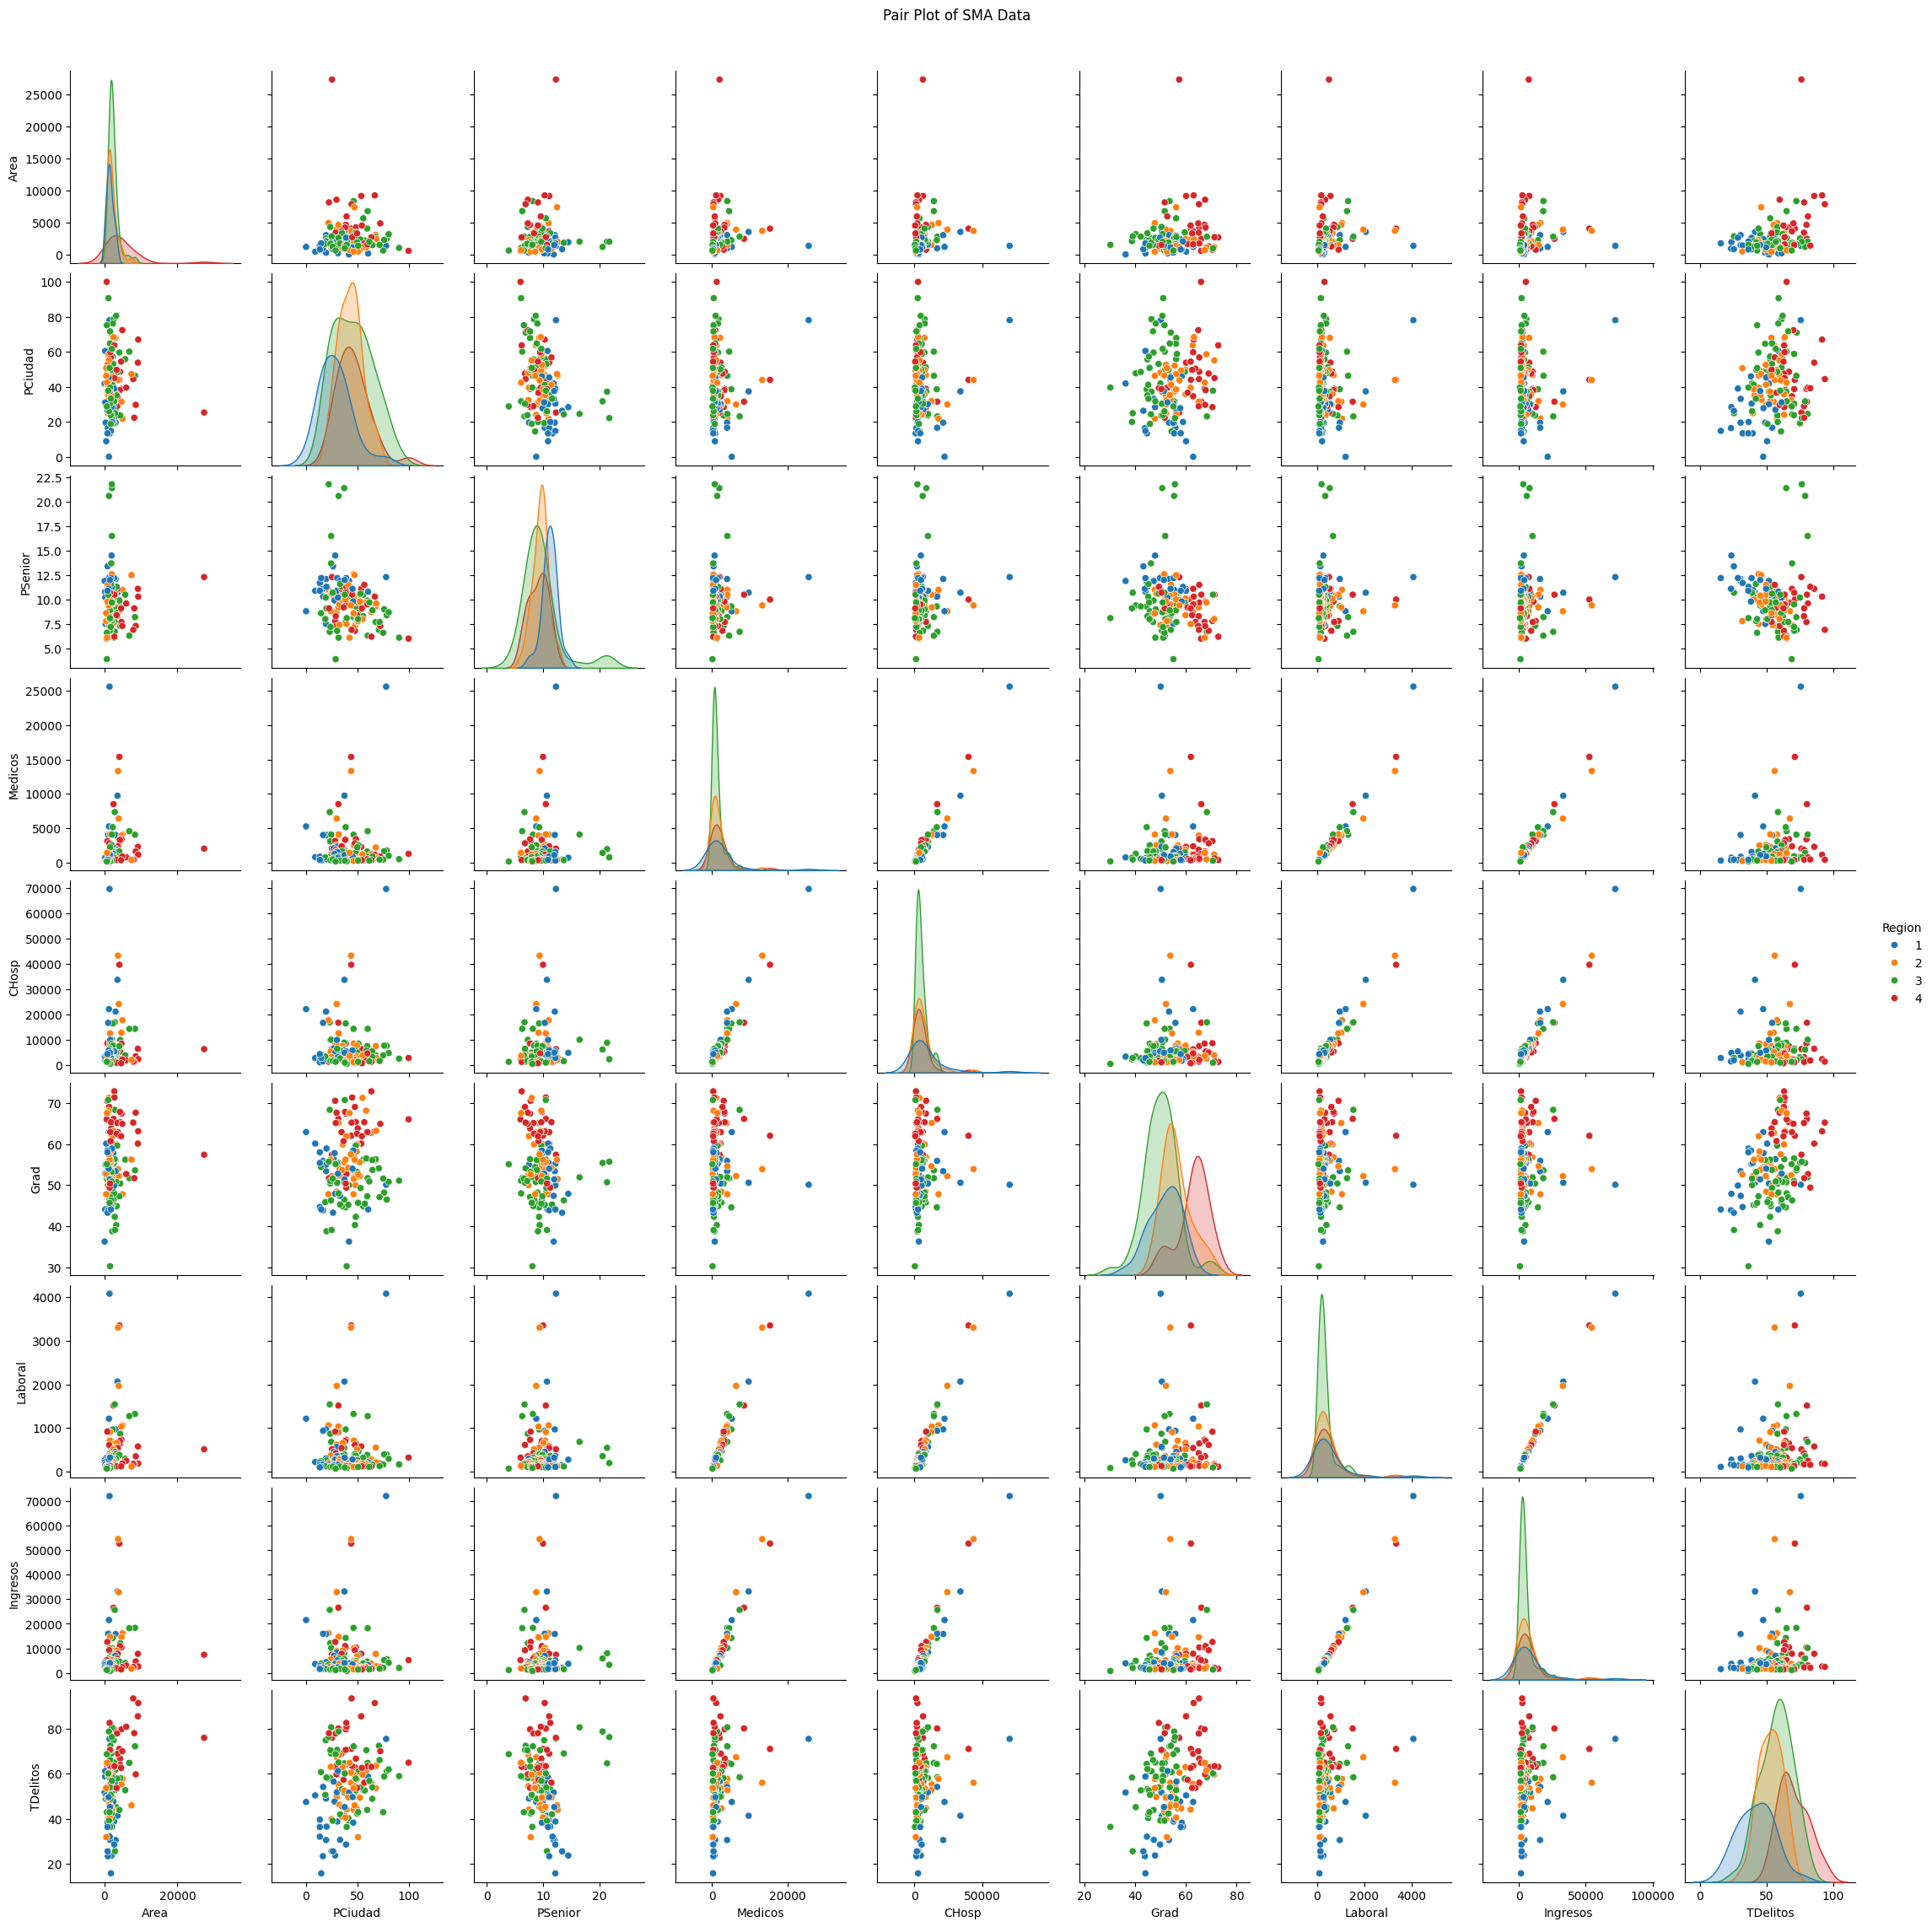

In [ ]:
# Eliminar variables Delitos y PobT, dado que ya fueron usadas para crear la variable de respuesta
sma = sma.drop(columns=['PobT', 'Delitos'])

# Reconocer la variable región como categórica
sma['Region'] = sma['Region'].astype('category')

# Explorar relaciones lineales gráficamente (equivalente a ggpairs)
sns.pairplot(sma, hue='Region', diag_kind='kde')
plt.suptitle('Pair Plot of SMA Data', y=1.02) # Adjust title position
plt.show()

   PCiudad  PSenior  Grad Region   TDelitos  log_Area  log_Medicos  log_CHosp  \
0                                                                               
1     78.1     12.3  50.1      1  75.554916  7.232733    10.151402  11.151640   
2     44.0     10.0  62.0      4  71.087043  8.311153     9.641408  10.589081   
3     43.9      9.4  53.9      2  56.029927  8.221210     9.497472  10.675723   
4     37.4     10.7  50.6      1  41.322904  8.175548     9.182352  10.426173   
5     29.9      8.8  52.2      2  67.383524  8.272826     8.764366  10.092743   

   log_Laboral  log_Ingresos  
0                             
1     8.314808     11.185809  
2     8.117790     10.873073  
3     8.103464     10.906726  
4     7.633515     10.410787  
5     7.584112     10.401410  


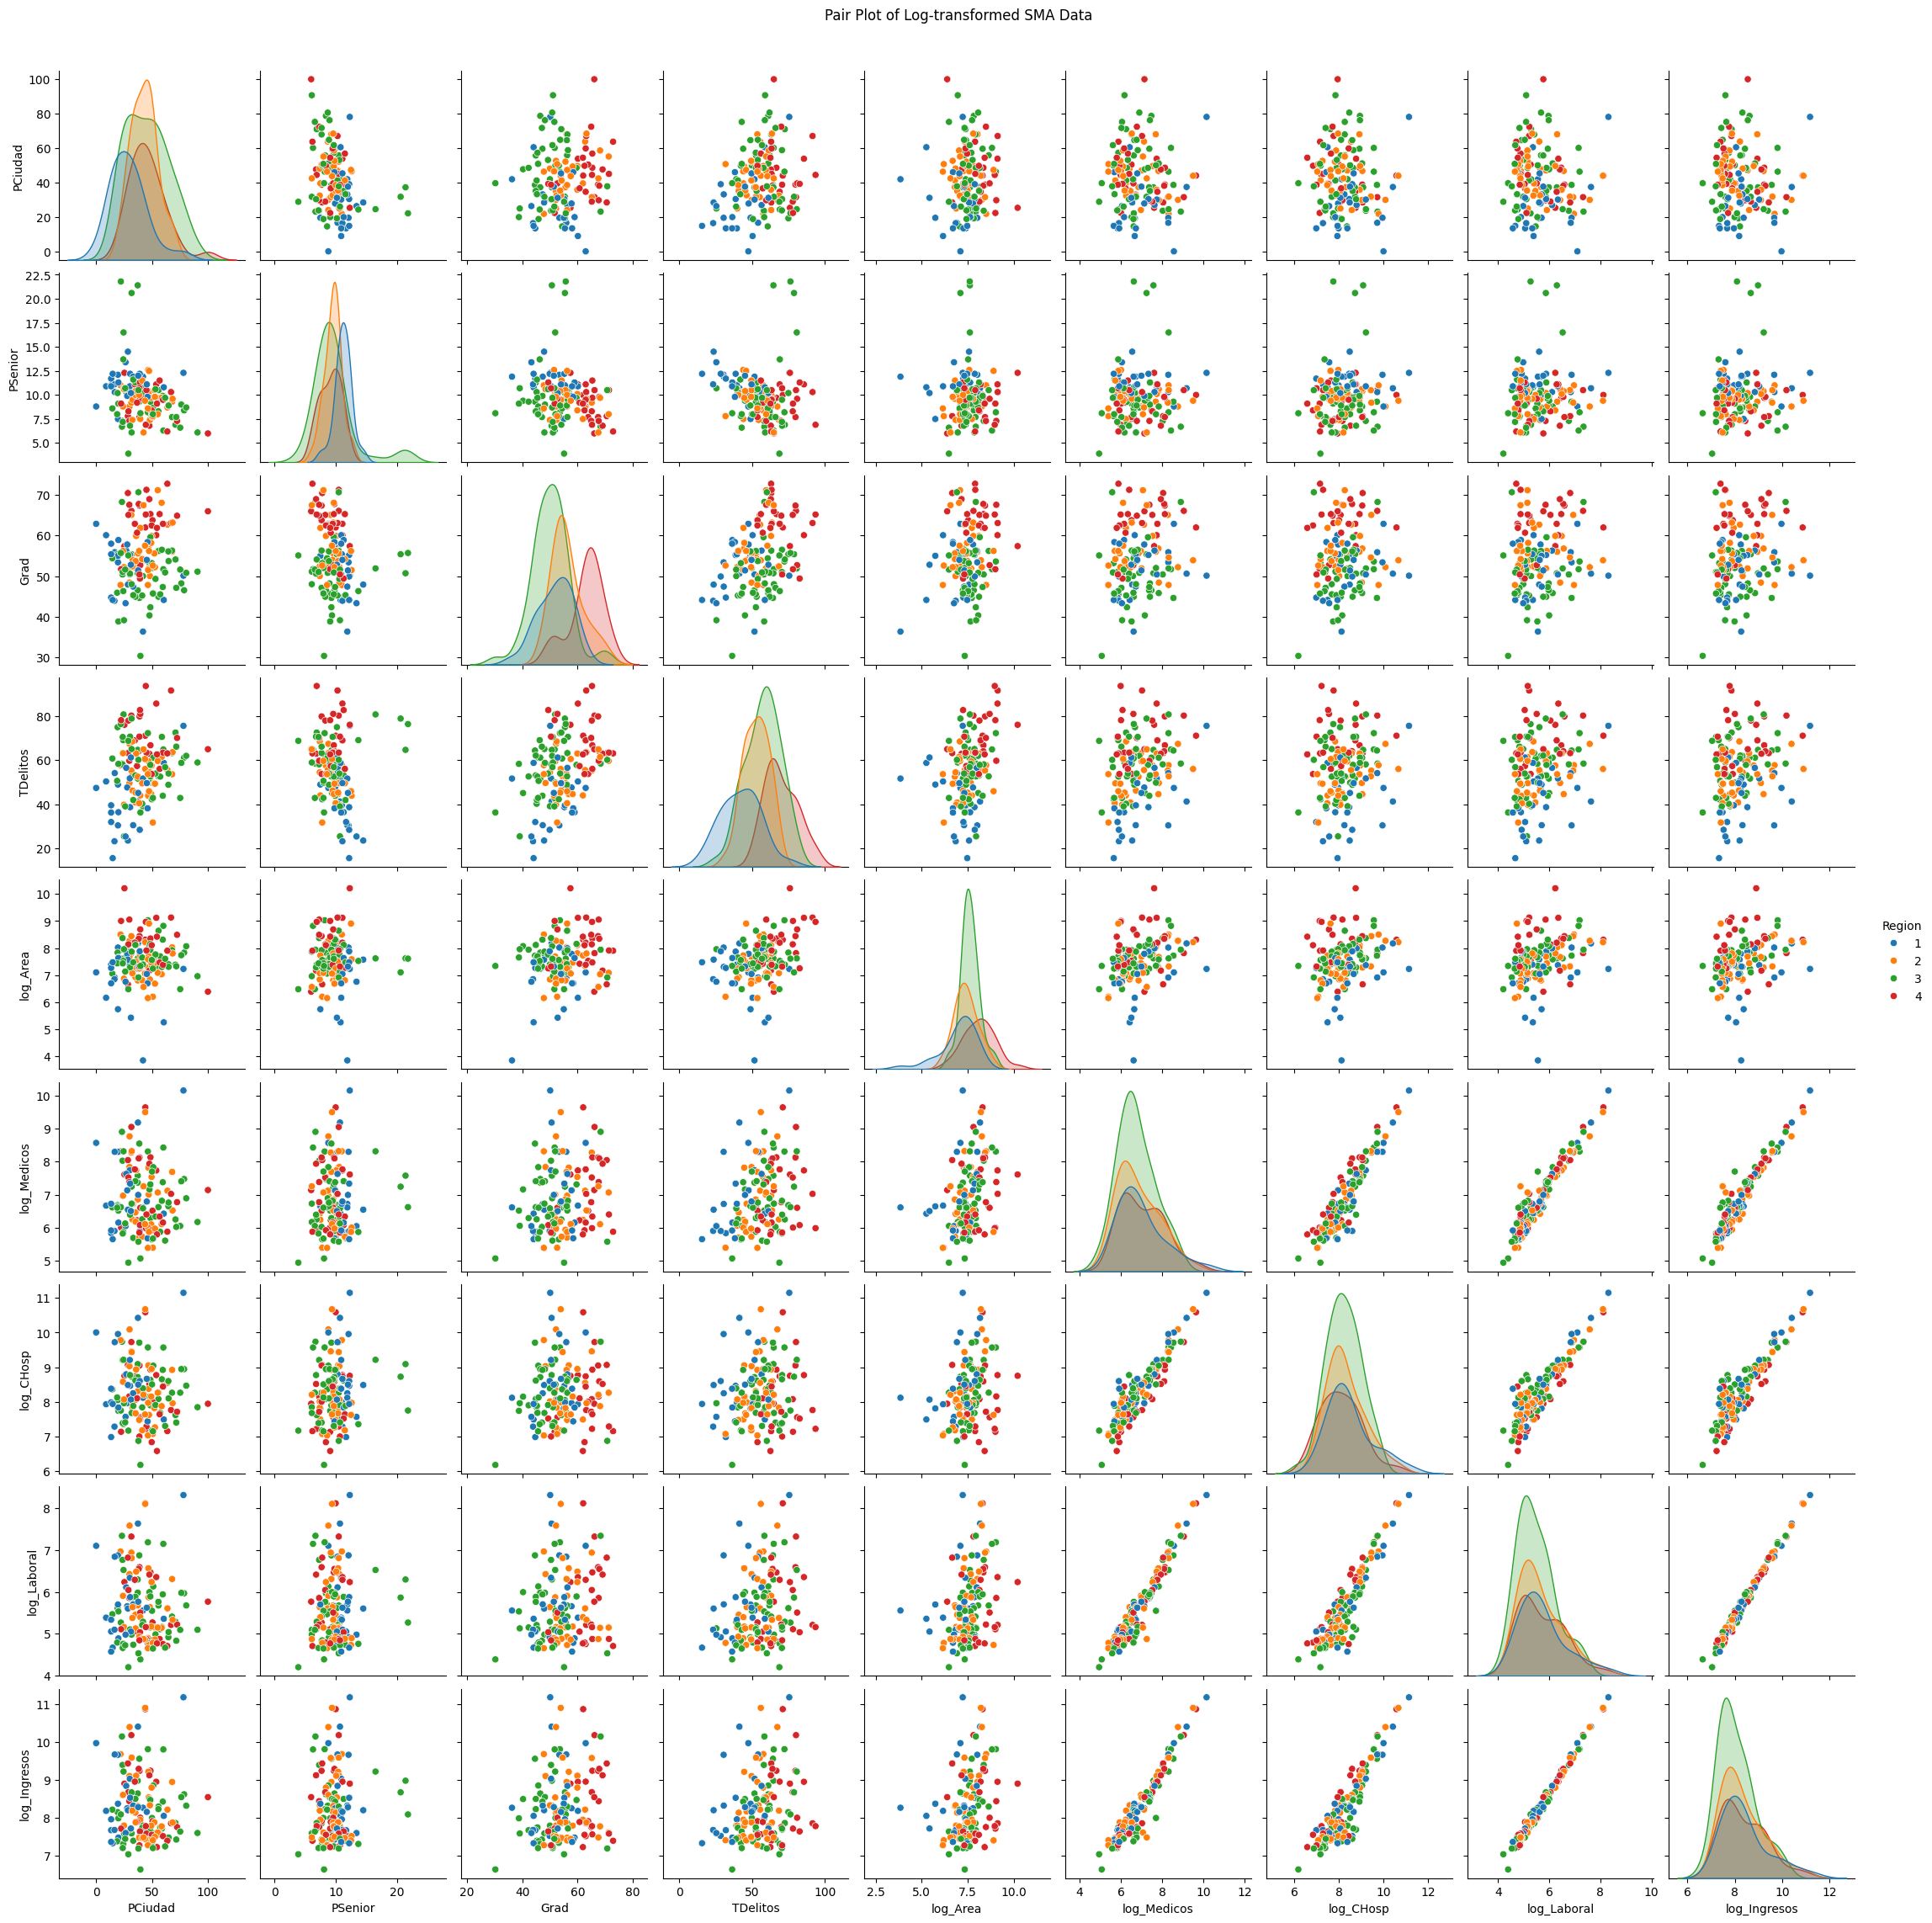

In [ ]:
# Transformar variables X con valores concentrados usando logaritmo
sma_log = sma.copy()
for col in ['Area', 'Medicos', 'CHosp', 'Laboral', 'Ingresos']:
    if col in sma_log.columns:
        sma_log[f'log_{col}'] = np.log(sma_log[col])
        sma_log = sma_log.drop(columns=[col])

print(sma_log.head())

sns.pairplot(sma_log, hue='Region', diag_kind='kde')
plt.suptitle('Pair Plot of Log-transformed SMA Data', y=1.02)
plt.show()

In [ ]:
# Function to calculate VIF using the inverse of the correlation matrix method
def calculate_vif_correlation_inverse(df):
    features = df.select_dtypes(include=np.number).columns
    df_numeric = df[features]
    corr_matrix = df_numeric.corr()
    if np.linalg.det(corr_matrix) == 0: # Check for singularity
        print("Warning: Correlation matrix is singular, VIF calculation from inverse might be unstable.")
        return pd.DataFrame(columns=["feature", "VIF"])
    inv_corr_matrix = np.linalg.inv(corr_matrix.values)
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_numeric.columns
    vif_data["VIF"] = np.diag(inv_corr_matrix)
    return vif_data

# Initial VIF calculation without TDelitos and Region
x_cols_initial = sma_log.drop(columns=['TDelitos', 'Region']).columns

print("Initial VIF values (Inverse Correlation Matrix Method):")
print(calculate_vif_correlation_inverse(sma_log[x_cols_initial]))

# Seleccionar solo 1 de las variables muy correlacionadas
# The R code selects and drops based on correlation and VIF. Let's replicate the drops.

# First drop: log_CHosp, log_Laboral
sma_log = sma_log.drop(columns=['log_CHosp', 'log_Laboral'], errors='ignore')
x_cols_after_drop1 = sma_log.drop(columns=['TDelitos'], errors='ignore').select_dtypes(include=np.number).columns # Only numerical for VIF calculation

print("VIF values after dropping log_CHosp, log_Laboral (Inverse Correlation Matrix Method):")
print(calculate_vif_correlation_inverse(sma_log[x_cols_after_drop1]))

# Second drop: log_Medicos
sma_log = sma_log.drop(columns=['log_Medicos'], errors='ignore')
x_cols_final = sma_log.drop(columns=['TDelitos'], errors='ignore').select_dtypes(include=np.number).columns # Only numerical for VIF calculation

print("VIF values after dropping log_Medicos (Inverse Correlation Matrix Method):")
print(calculate_vif_correlation_inverse(sma_log[x_cols_final]))

print("\nFinal DataFrame for modeling (sma_log.head()):")
print(sma_log.head())

Initial VIF values (Inverse Correlation Matrix Method):
        feature         VIF
0       PCiudad    1.173416
1       PSenior    1.203080
2          Grad    1.509970
3      log_Area    1.290874
4   log_Medicos   18.408763
5     log_CHosp    7.493302
6   log_Laboral  135.031846
7  log_Ingresos  121.570922
VIF values after dropping log_CHosp, log_Laboral (Inverse Correlation Matrix Method):
        feature        VIF
0       PCiudad   1.138021
1       PSenior   1.139610
2          Grad   1.137348
3      log_Area   1.147031
4   log_Medicos  12.414573
5  log_Ingresos  12.092170
VIF values after dropping log_Medicos (Inverse Correlation Matrix Method):
        feature       VIF
0       PCiudad  1.112905
1       PSenior  1.139330
2          Grad  1.107860
3      log_Area  1.124340
4  log_Ingresos  1.130602

Final DataFrame for modeling (sma_log.head()):
   PCiudad  PSenior  Grad Region   TDelitos  log_Area  log_Ingresos
0                                                                  
1 

# Paso 3. Estimación del modelo de regresión lineal múltiple

In [ ]:
# Estimación del modelo de regresión lineal múltiple (TDelitos ~ .)
# Convert Region to C(Region) for categorical treatment in statsmodels formula
# Ensure that the formula string is not empty or malformed

independent_vars = [col for col in sma_log.columns if col not in ['TDelitos']]
if not independent_vars:
    # Fallback if no independent variables are left (should not happen after fixes)
    formula = 'TDelitos ~ 1' # Intercept only model
else:
    formula = 'TDelitos ~ ' + ' + '.join(independent_vars)

# Explicitly convert 'Region' to categorical for statsmodels formula to ensure correct handling
sma_log['Region'] = sma_log['Region'].astype('category')

modelo = smf.ols(formula=formula, data=sma_log).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               TDelitos   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     15.46
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           6.93e-16
Time:                        23:05:32   Log-Likelihood:                -529.36
No. Observations:                 141   AIC:                             1077.
Df Residuals:                     132   BIC:                             1103.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -9.5951     13.697     -0.701   

# Paso 4. Comprobación de supuestos

La función `diagnorm` de R es una función personalizada para diagnósticos de residuos. En Python, utilizaremos métodos estándar de `statsmodels` y `seaborn`/`matplotlib` para visualizar y probar los supuestos del modelo de regresión lineal múltiple:

1.  **Normalidad de los residuos:** Q-Q plot de los residuos estandarizados, histograma de residuos.
2.  **Homocedasticidad:** Gráfico de residuos estandarizados vs. valores ajustados.
3.  **Independencia de los residuos:** (No directamente abordado por `diagnorm`, pero implícitamente por los gráficos de residuos vs. índice o tiempo).
4.  **Ausencia de multicolinealidad:** Ya lo comprobamos con VIF.

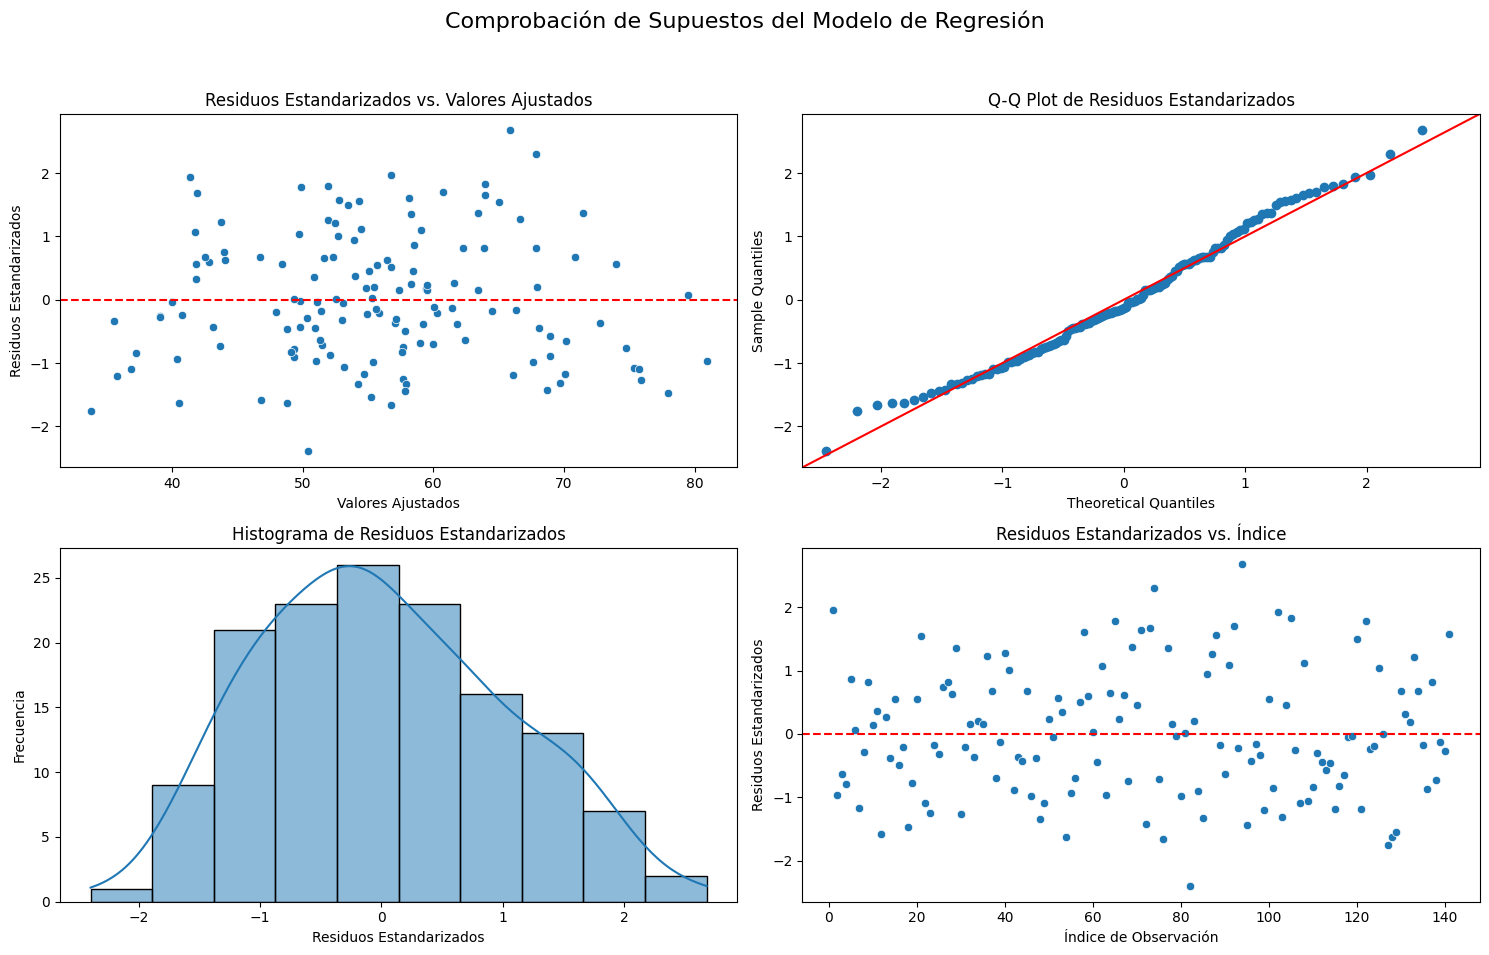

In [ ]:
# Residuos estandarizados
standardized_residuals = modelo.get_influence().resid_studentized_internal

# Valores ajustados
fitted_values = modelo.fittedvalues

# Plots para la comprobación de supuestos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comprobación de Supuestos del Modelo de Regresión', fontsize=16)

# 1. Residuos estandarizados vs. Valores ajustados (Homocedasticidad)
sns.scatterplot(x=fitted_values, y=standardized_residuals, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos Estandarizados')
axes[0, 0].set_title('Residuos Estandarizados vs. Valores Ajustados')

# 2. Q-Q plot de residuos (Normalidad)
sm.qqplot(standardized_residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot de Residuos Estandarizados')

# 3. Histograma de Residuos (Normalidad)
sns.histplot(standardized_residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel('Residuos Estandarizados')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de Residuos Estandarizados')

# 4. Residuos estandarizados vs. Índice (Independencia)
sns.scatterplot(x=sma_log.index, y=standardized_residuals, ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Índice de Observación')
axes[1, 1].set_ylabel('Residuos Estandarizados')
axes[1, 1].set_title('Residuos Estandarizados vs. Índice')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# Pruebas estadísticas adicionales para los supuestos

# Prueba de normalidad de Shapiro-Wilk para los residuos
# H0: Los residuos siguen una distribución normal.
# H1: Los residuos no siguen una distribución normal.
from scipy.stats import shapiro
shapiro_test = shapiro(standardized_residuals)
print(f"\nPrueba de Shapiro-Wilk para la normalidad de los residuos:\nEstadístico W: {shapiro_test.statistic:.3f}, p-valor: {shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue < 0.05:
    print("Se rechaza la hipótesis nula: los residuos no son normales (p-valor < 0.05).")
else:
    print("No se rechaza la hipótesis nula: los residuos parecen normales (p-valor >= 0.05).")

# Prueba de Breusch-Pagan para la homocedasticidad
# H0: Homocedasticidad (varianza de los errores constante).
# H1: Heterocedasticidad (varianza de los errores no constante).
from statsmodels.stats.api import het_breuschpagan
# The exog for breuschpagan should be the independent variables used in the model
bp_test = het_breuschpagan(modelo.resid, modelo.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(f"\nPrueba de Breusch-Pagan para homocedasticidad:\nLM Statistic: {bp_test[0]:.3f}, p-valor LM: {bp_test[1]:.3f}")
if bp_test[1] < 0.05:
    print("Se rechaza la hipótesis nula: hay heterocedasticidad (p-valor LM < 0.05).")
else:
    print("No se rechaza la hipótesis nula: parece haber homocedasticidad (p-valor LM >= 0.05).")


Prueba de Shapiro-Wilk para la normalidad de los residuos:
Estadístico W: 0.985, p-valor: 0.128
No se rechaza la hipótesis nula: los residuos parecen normales (p-valor >= 0.05).

Prueba de Breusch-Pagan para homocedasticidad:
LM Statistic: 14.799, p-valor LM: 0.063
No se rechaza la hipótesis nula: parece haber homocedasticidad (p-valor LM >= 0.05).


# Paso 5. Inferencias

In [ ]:
# Pruebas de hipótesis (disponibles en el resumen del modelo estimado)
print("\nResumen del modelo:")
print(modelo.summary())

# Intervalo de confianza para coeficientes beta
print("\nIntervalos de confianza al 95% para los coeficientes:\n", modelo.conf_int(alpha=0.05))


Resumen del modelo:
                            OLS Regression Results                            
Dep. Variable:               TDelitos   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     15.46
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           6.93e-16
Time:                        23:05:33   Log-Likelihood:                -529.36
No. Observations:                 141   AIC:                             1077.
Df Residuals:                     132   BIC:                             1103.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -9.5951    

In [ ]:
# Intervalo de predicción para un área metropolitana de la región sur con las características promedio de la región

# Debugging information
print("DEBUG: Type of sma_log['Region']:", sma_log['Region'].dtype)
print("DEBUG: Categories of sma_log['Region']:", sma_log['Region'].cat.categories)
print("DEBUG: Value counts for sma_log['Region']:\n", sma_log['Region'].value_counts())

# Crear un DataFrame con los promedios de las variables numéricas para la Región 3
# Ensure 'Region' is filtered correctly using integer comparison for categories.
region_to_filter = 3 # This is an int
print(f"DEBUG: Filtering for Region == {region_to_filter}")

# Filter using the integer value, which should work for categorical columns with integer categories
region_3_data = sma_log[sma_log['Region'] == region_to_filter]

print("DEBUG: Shape of region_3_data after filter:", region_3_data.shape)

# Check if region_3_data is empty
if region_3_data.empty:
    print(f"ERROR: No data found for Region {region_to_filter}. Cannot calculate mean for prediction.")
    # Create an empty DataFrame to avoid errors later, or raise a more specific error
    new_data_mean = pd.DataFrame(columns=sma_log.drop(columns=['Region', 'TDelitos'], errors='ignore').columns)
else:
    new_data_mean = region_3_data.drop(columns=['Region', 'TDelitos'], errors='ignore').mean().to_frame().T

print("DEBUG: new_data_mean after mean calculation:\n", new_data_mean)

# Create a new DataFrame for prediction with the correct structure
# We need to ensure that the 'Region' column is explicitly set as a category '3'
predict_df = pd.DataFrame(new_data_mean.iloc[0]).T # Start with the mean numeric values (will be NaN if new_data_mean was empty)

# Get all categories from the original 'Region' column in sma_log (which are integers)
all_region_categories = sma_log['Region'].cat.categories

# Ensure the value being put into Categorical is of the same type as categories
# This makes sure that '3' (int) is used, not '3' (str)
target_region_value_as_category = None
if region_to_filter in all_region_categories:
    target_region_value_as_category = region_to_filter # Use the integer directly
else:
    print(f"WARNING: Region {region_to_filter} is not in the model's trained categories: {all_region_categories}")
    # Fallback, this should ideally not happen if data is consistent
    target_region_value_as_category = all_region_categories[0] # Use first category as a default

predict_df['Region'] = pd.Categorical([target_region_value_as_category], categories=all_region_categories)

print("\nDataFrame para la predicción (newdf):\n", predict_df)

# Realizar la predicción con intervalo de confianza y predicción
# Only attempt prediction if new_data_mean was not empty (i.e., predict_df has valid data)
if not new_data_mean.empty and not predict_df.isnull().values.any(): # Check if predict_df has NaNs from empty means
    predictions = modelo.get_prediction(predict_df)
    summary_frame = predictions.summary_frame(alpha=0.05)
    print("\nIntervalo de predicción al 95% para la Región 3 (con características promedio):\n", summary_frame)
else:
    print("\nNo se pudo generar el intervalo de predicción debido a datos faltantes o un DataFrame de predicción vacío.")

DEBUG: Type of sma_log['Region']: category
DEBUG: Categories of sma_log['Region']: Index([1, 2, 3, 4], dtype='int64')
DEBUG: Value counts for sma_log['Region']:
 Region
3    51
2    35
4    28
1    27
Name: count, dtype: int64
DEBUG: Filtering for Region == 3
DEBUG: Shape of region_3_data after filter: (51, 7)
DEBUG: new_data_mean after mean calculation:
      PCiudad   PSenior      Grad  log_Area  log_Ingresos
0  45.592157  9.676471  50.12549  7.622061      8.070608

DataFrame para la predicción (newdf):
      PCiudad   PSenior      Grad  log_Area  log_Ingresos Region
0  45.592157  9.676471  50.12549  7.622061      8.070608      3

Intervalo de predicción al 95% para la Región 3 (con características promedio):
         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  57.412136  1.495476      54.453936      60.370336     36.080252   

   obs_ci_upper  
0     78.744021  
